# Capítulo 15: Inferência bayesiana

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [1]:
# Pág. 443
import numpy as np
np.random.seed(10)
# probabilidade de sair cara
theta_pop = 0.2
n = 50 # número de lançamentos
X = np.zeros(n)
# gera os dados
for i in range(0,n):
    if(np.random.uniform() <= theta_pop):
        X[i] = 1
theta_hat_freq = np.sum(X)/len(X)
print('X:',X)

X: [0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1.]


In [4]:
# Pág. 444
# First, install the pymc package
!pip install pymc
import pymc as pm

with pm.Model() as model:
    # define a distribuição a priori
    # vamos usar uma distribuição beta
    theta = pm.Beta('theta', alpha=2, beta=2)

    # define a função de verossimilhança
    observation = pm.Bernoulli('obs', p=theta, observed=X)
    # realiza a inferência
    trace = pm.sample(10000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1 seconds.


In [8]:
# Pág. 444
map_estimate = pm.find_MAP(model=model)
print(map_estimate)

Output()

{'theta_logodds__': array(-1.20397279), 'theta': array(0.23076923)}


<Axes: title={'center': 'theta'}>

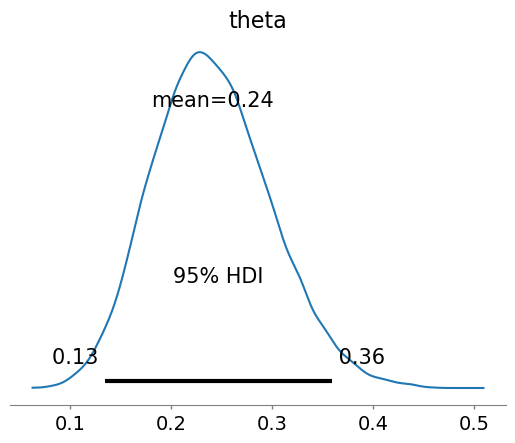

In [9]:
# Pág. 444
import arviz as az
az.plot_posterior(trace, hdi_prob=0.95)

Text(0, 0.5, 'p(x)')

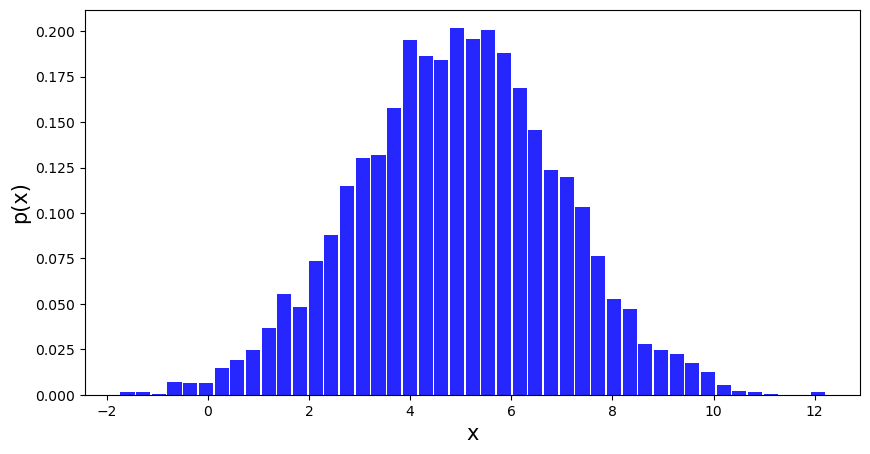

In [10]:
# Pág. 445
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(10)
# gera os dados
N = 5000 # tamanho da população
mu_pop = 5 # média populacional
stdev_pop = 2 # desvio padrão
# gera os dados
data = np.random.normal(mu_pop,stdev_pop, N)
# mostra a distribuição dos dados
plt.figure(figsize=(10, 5))
plt.hist(data, rwidth=0.9, bins='auto', 
         alpha=0.85,color="blue", density=True)
plt.xlabel("x", fontsize = 15)
plt.ylabel("p(x)", fontsize = 15)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, stdev]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 2 seconds.


array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'stdev'}>],
      dtype=object)

<Figure size 1000x500 with 0 Axes>

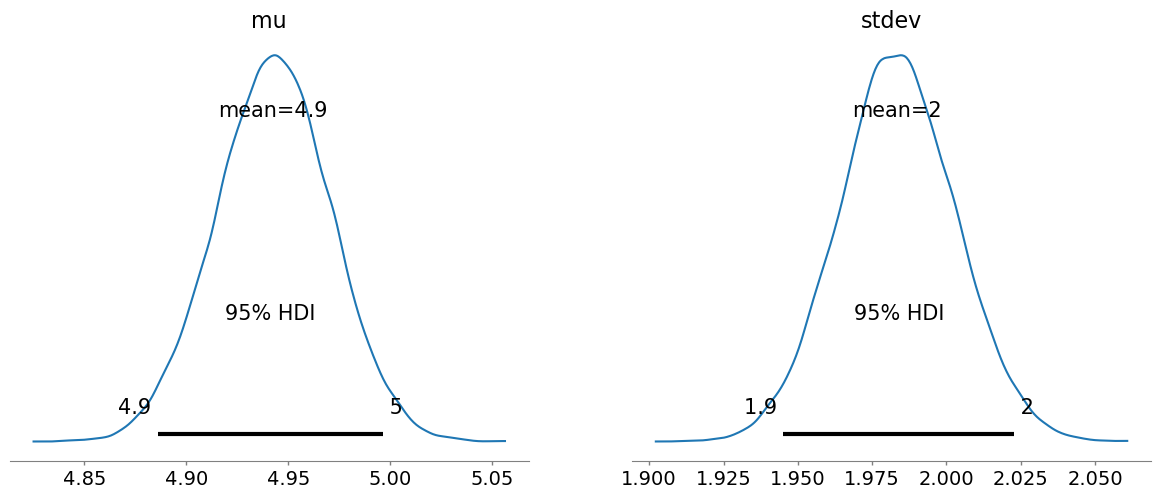

In [11]:
# Pág. 446
import pymc as pm
import arviz as az
from matplotlib import pyplot as plt

with pm.Model() as model:
    # define as distribuições a priori   
    # priori da média
    mu = pm.Normal('mu', mu = 0.0,sigma = 20)
    # priori do desvio padrão
    stdev = pm.HalfNormal('stdev', sigma=10)
    # função de verossimilhança
    observation = pm.Normal('obs', mu=mu, sigma=stdev, 
                            observed=data)
    # realiza a inferência
    trace = pm.sample(10000, tune=1000)

# mostra as distribuições a posteriori
plt.figure(figsize=(10, 5))
az.plot_posterior(trace, hdi_prob=0.95)

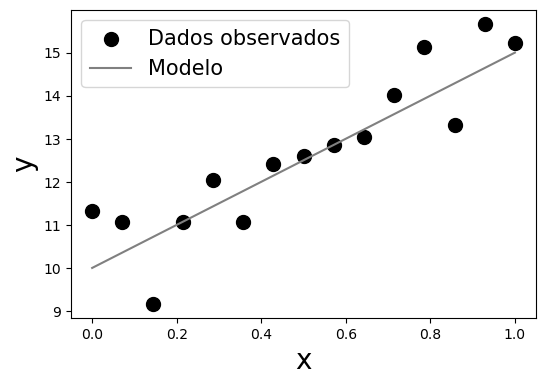

In [12]:
# Pág. 447
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

# parâmetros do modelo
beta_0_model = 10
beta_1_model = 5
sigma_model = 1
# número de observações
num_points = 15
# gera os dados
x = np.linspace(0, 1, num_points)
y_model = beta_0_model + beta_1_model*x
y = y_model + np.random.normal(scale=sigma_model, 
                               size=num_points)
# mostra os dados e o modelo
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=100,c='k', 
            label = 'Dados observados')
plt.plot(x, y_model, color='gray', 
         label = 'Modelo')
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, beta_0, beta_1]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 2 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


array([<Axes: title={'center': 'beta_0'}>,
       <Axes: title={'center': 'beta_1'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

<Figure size 1000x500 with 0 Axes>

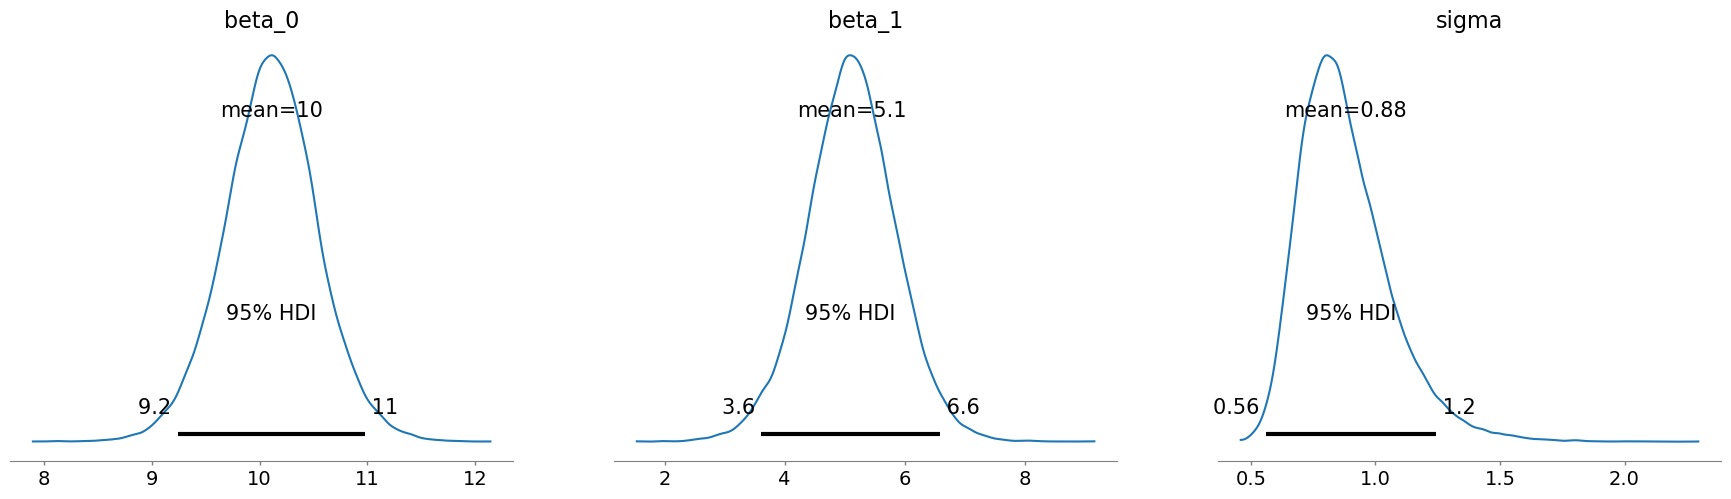

In [13]:
# Pág. 448
import pymc as pm
import arviz as az

with pm.Model() as model:
    # distribuições a priori
    sigma = pm.Exponential("sigma", lam = 1.0)
    beta_0 = pm.Normal("beta_0", mu=0, sigma=20) 
    beta_1 = pm.Normal("beta_1", mu=0, sigma=20) 
    # Verossimilhança
    observations = pm.Normal("obs",mu=beta_0 + beta_1*x, 
                             sigma=sigma, observed=y)
    # Faz a estimação
    trace = pm.sample(10000, tune=1000)
# mostra as distribuições a posteriori
plt.figure(figsize=(10, 5))
az.plot_posterior(trace, hdi_prob=0.95)

Output()

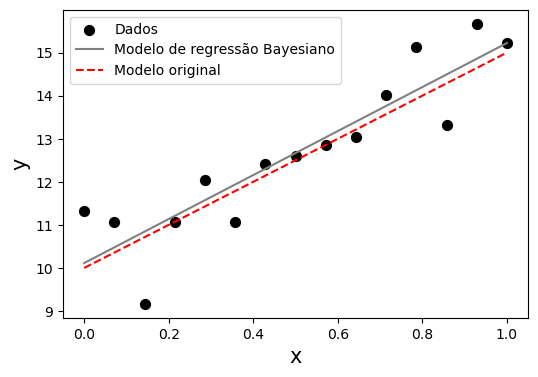

In [15]:
# Pág. 449
# modelo ajustado
map_estimate = pm.find_MAP(model=model)
y_Bayes = map_estimate['beta_0'] + map_estimate['beta_1']*x

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=50,c='k', label = 'Dados')
plt.plot(x, y_Bayes, color='gray', 
         label = 'Modelo de regressão Bayesiano')
plt.plot(x, y_model, color='red',linestyle='dashed', 
         label = 'Modelo original')
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.legend(fontsize = 10)
plt.show(True)

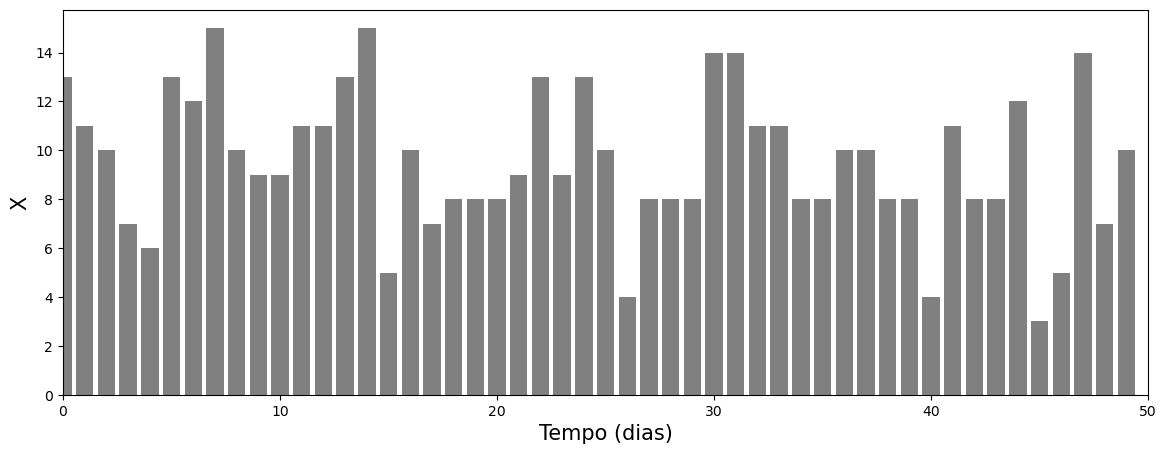

In [16]:
# Pág. 452
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import poisson

np.random.seed(10)
# lambda da população
lambda_pop = 10
N = 50 # tamanho da amostra
count_data = poisson.rvs(mu=lambda_pop, size=N)
n_count_data = len(count_data)
# mostra os dados gerados
plt.figure(figsize=(14,5))
plt.bar(np.arange(n_count_data), count_data, 
        color="gray")
plt.xlabel("Tempo (dias)",fontsize=15)
plt.ylabel("X", fontsize=15)
plt.xlim(0, n_count_data);
plt.show(True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda1]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1 seconds.


<Axes: title={'center': 'lambda1'}>

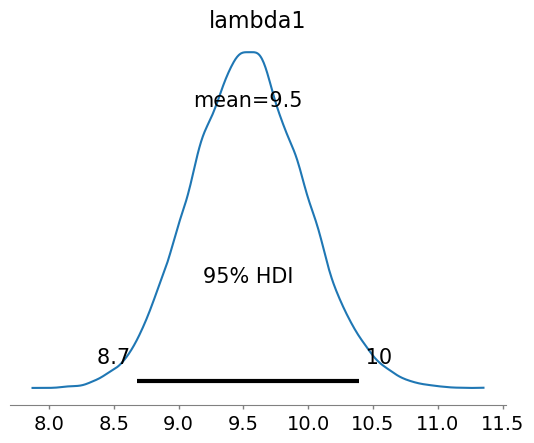

In [17]:
# Pág. 453
import pymc as pm
import arviz as az

with pm.Model() as model:
    # define as distribuições a priori
    alpha = 1.0/np.mean(count_data)
    lambda1 = pm.Exponential("lambda1", lam=alpha)

    # função de verossimilhança
    observation = pm.Poisson('obs', mu=lambda1, observed=count_data)

    # realiza a inferência
    trace = pm.sample(10000, tune=1000)

# mostra a distribuição a posteriori
az.plot_posterior(trace, hdi_prob=0.95)